In [1]:
import matplotlib.pyplot as plt
from mxlpy import Simulator, make_protocol
from mxlmodels import get_lam2026

In [2]:
pwd

'/home/huy/Huy/mxl-models/docs'

In [3]:
m_file = "../src/mxlmodels/data/lam2026/Codes/Lifetime_WT_model.m"

with open(m_file, 'r', encoding='utf-8') as f:
        content = f.read()

In [4]:
content

'function [varargout] = Lifetime_WT_model(data_in, Delta_T_in, par_in)\n%   input lifetime data array, light seq, initial parameters to compute time-dependent lifetime value.\n% > data_in: format as [TimePoint , lifetimedata]\n% > Delta_T_in: \n%       (1) Dark-Light period duration (N * 1 column vector).\n%           ex: Delta_T_in = [0, 5, 5] for L5-D5 seq.\n%       (2) continuous Light/Dark periodic cycle (single value)\n%           ex: = 10 for L5-D5-...\n% > par_in: Initial parameters (n * 1 Vector)\n\n% Author: Rebecca Lee, Tsung-Yen Lee\n% Date: 2025.5.29\n% Version: 1.03\n\n\n% set up the light intenstity function\nI_max = 1.0 ; % max value of I\nDeltaT = Delta_T_in ; % period of the I(t) square wave\nif (length(DeltaT) == 1)\n    % function returning I(t)\n    I = @(t) I_max * 0.5*(-sign(mod(t,(DeltaT))-0.5*DeltaT)+1) + 1;\nelse\n    DeltaT_sum = cumsum(DeltaT) ;\n    I = @(t) I_max * mod(sum(t>=DeltaT_sum),2) + 1;\nend\n\ndata_time = data_in(:,1);\ntime = 0:0.1:sum(DeltaT);\n

In [9]:
s = Simulator(get_lam2026()
              .update_parameter('ppfd', 100)
              .update_parameters({'tau_0': 1.5})
              .update_variables({"PL": 45.4 *0.2})
              ).simulate(60*20)

res = s.get_result().unwrap_or_err().get_combined()
res.index = res.index/60

In [3]:
get_lam2026().get_stoichiometries()

,VA,AV,AZ,ZA,PAf,PAb,PZf,PZb,PVf,PVb,QVf,QVb,QAf,QAb,QZf,QZb,QLf,QLb,damage,v_alpha_VDE
A,1.0,-1.0,-1.0,1.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Z,0.0,0.0,1.0,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PV,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PA,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0
QV,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
QA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
QZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
PL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
QL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0


<Axes: >

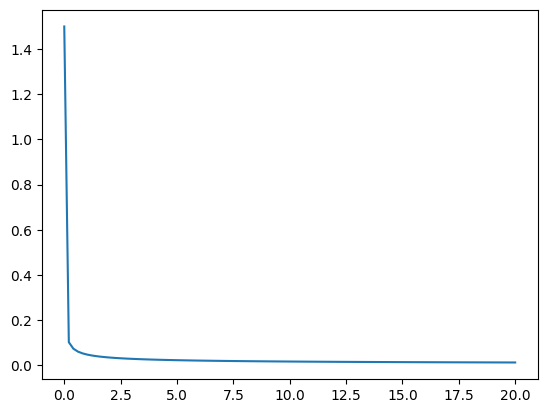

In [11]:
(res['tau_Fluo']).plot()